# Notebook 07 — Time Series Decomposition, Stationarity Analysis 

Thực hiện phân rã chuỗi thời gian, kiểm định tính dừng 


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data_loader import load_processed
from pathlib import Path

FIG_DIR = Path('../outputs/figures/model')
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
%matplotlib inline

In [3]:
sales      = load_processed('sales_clean.csv')
orders     = load_processed('orders_clean.csv')
order_items = load_processed('order_items_clean.csv')
products   = load_processed('products_clean.csv')
returns    = load_processed('returns_clean.csv')
web_traffic = load_processed('web_traffic_clean.csv')
payments   = load_processed('payments_clean.csv')
promotions = load_processed('promotions_clean.csv')

d:\KienTap_RevenueEcommerce\revenue_forecast_ecommerce\notebooks\..\src\data_loader.py:40: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(PROCESSED / subfolder / filename)


### 1. Biến đổi dữ liệu: log doanh thu dựa trên xu hướng biến động


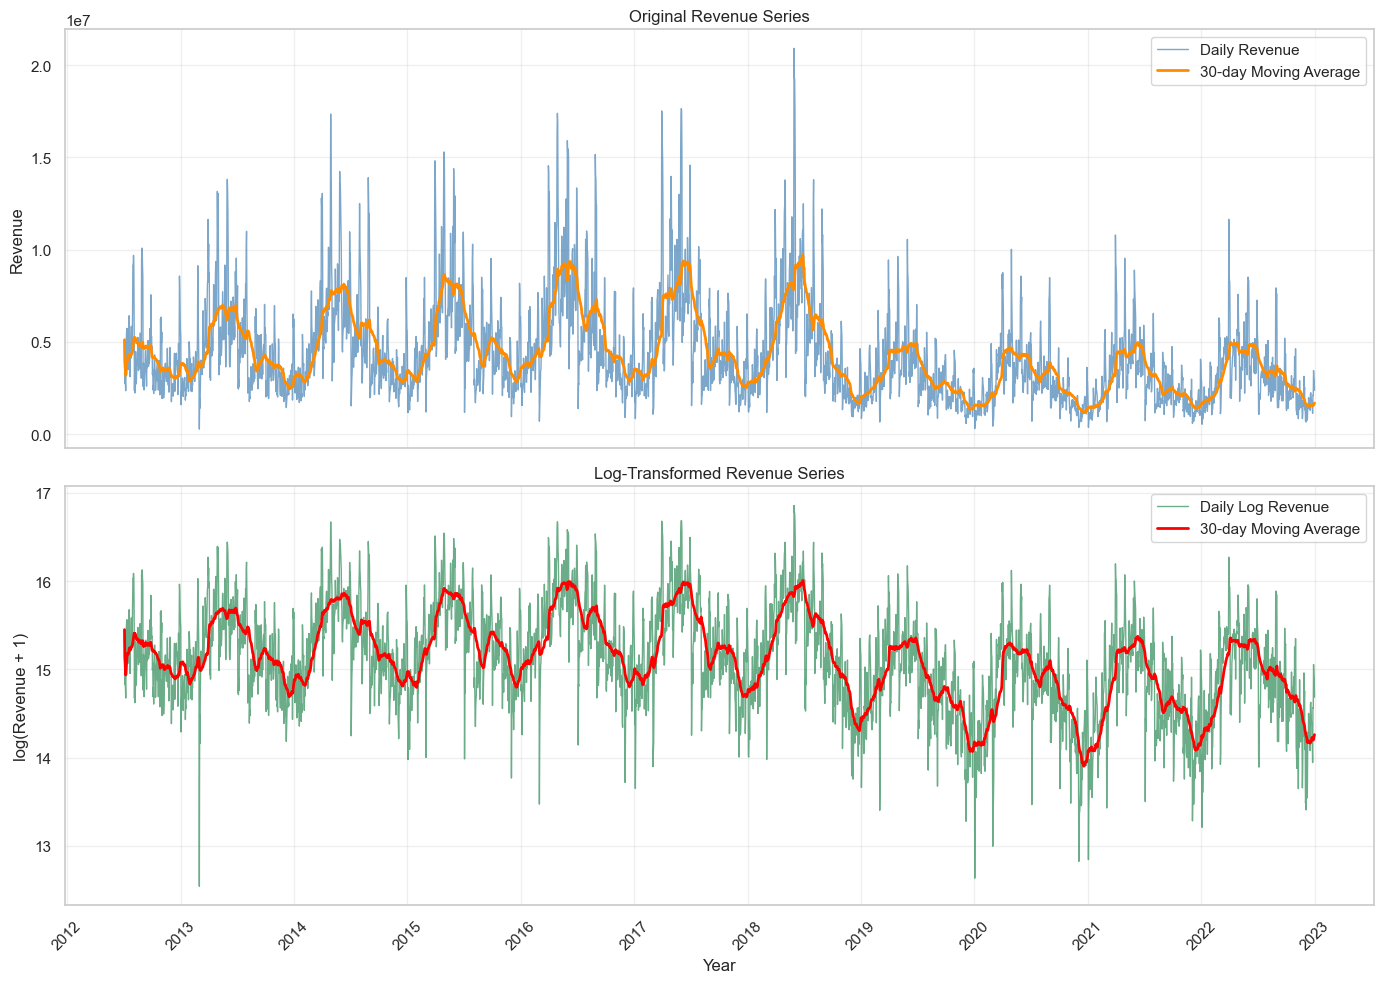

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Đảm bảo kiểu dữ liệu
sales['date'] = pd.to_datetime(sales['date'])

# Tạo log revenue
sales['log_revenue'] = np.log1p(sales['revenue'])

# Sắp xếp theo thời gian
plot_df = sales[['date', 'revenue', 'log_revenue']].copy()
plot_df = plot_df.sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ======================
# Revenue gốc
# ======================
axes[0].plot(
    plot_df['date'],
    plot_df['revenue'],
    color='steelblue',
    linewidth=1,
    alpha=0.7,
    label='Daily Revenue'
)

axes[0].plot(
    plot_df['date'],
    plot_df['revenue'].rolling(30, min_periods=1).mean(),
    color='darkorange',
    linewidth=2,
    label='30-day Moving Average'
)

axes[0].set_title('Original Revenue Series')
axes[0].set_ylabel('Revenue')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ======================
# Log Revenue
# ======================
axes[1].plot(
    plot_df['date'],
    plot_df['log_revenue'],
    color='seagreen',
    linewidth=1,
    alpha=0.7,
    label='Daily Log Revenue'
)

axes[1].plot(
    plot_df['date'],
    plot_df['log_revenue'].rolling(30, min_periods=1).mean(),
    color='red',
    linewidth=2,
    label='30-day Moving Average'
)

axes[1].set_title('Log-Transformed Revenue Series')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('log(Revenue + 1)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Format trục thời gian
ax = axes[1]
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Đường **trung bình động (Moving Average)** trên chuỗi `log_revenue` dao động với biên độ tương đối ổn định qua các năm, phản ánh sự cải thiện về **tính đồng nhất của phương sai** sau khi áp dụng phép biến đổi logarit.

Nhờ vậy, **phép biến đổi logarit** giúp ổn định phương sai, giảm ảnh hưởng của các *giá trị ngoại lệ* và làm rõ cấu trúc xu hướng của chuỗi doanh thu. Điều này tạo điều kiện thuận lợi cho các **kiểm định thống kê** và quá trình xây dựng **mô hình dự báo chuỗi thời gian**.

# 2. STL Decomposition

Missing days after reindexing: 0


C:\Users\lenovo\AppData\Local\Temp\ipykernel_26116\1787031774.py:71: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


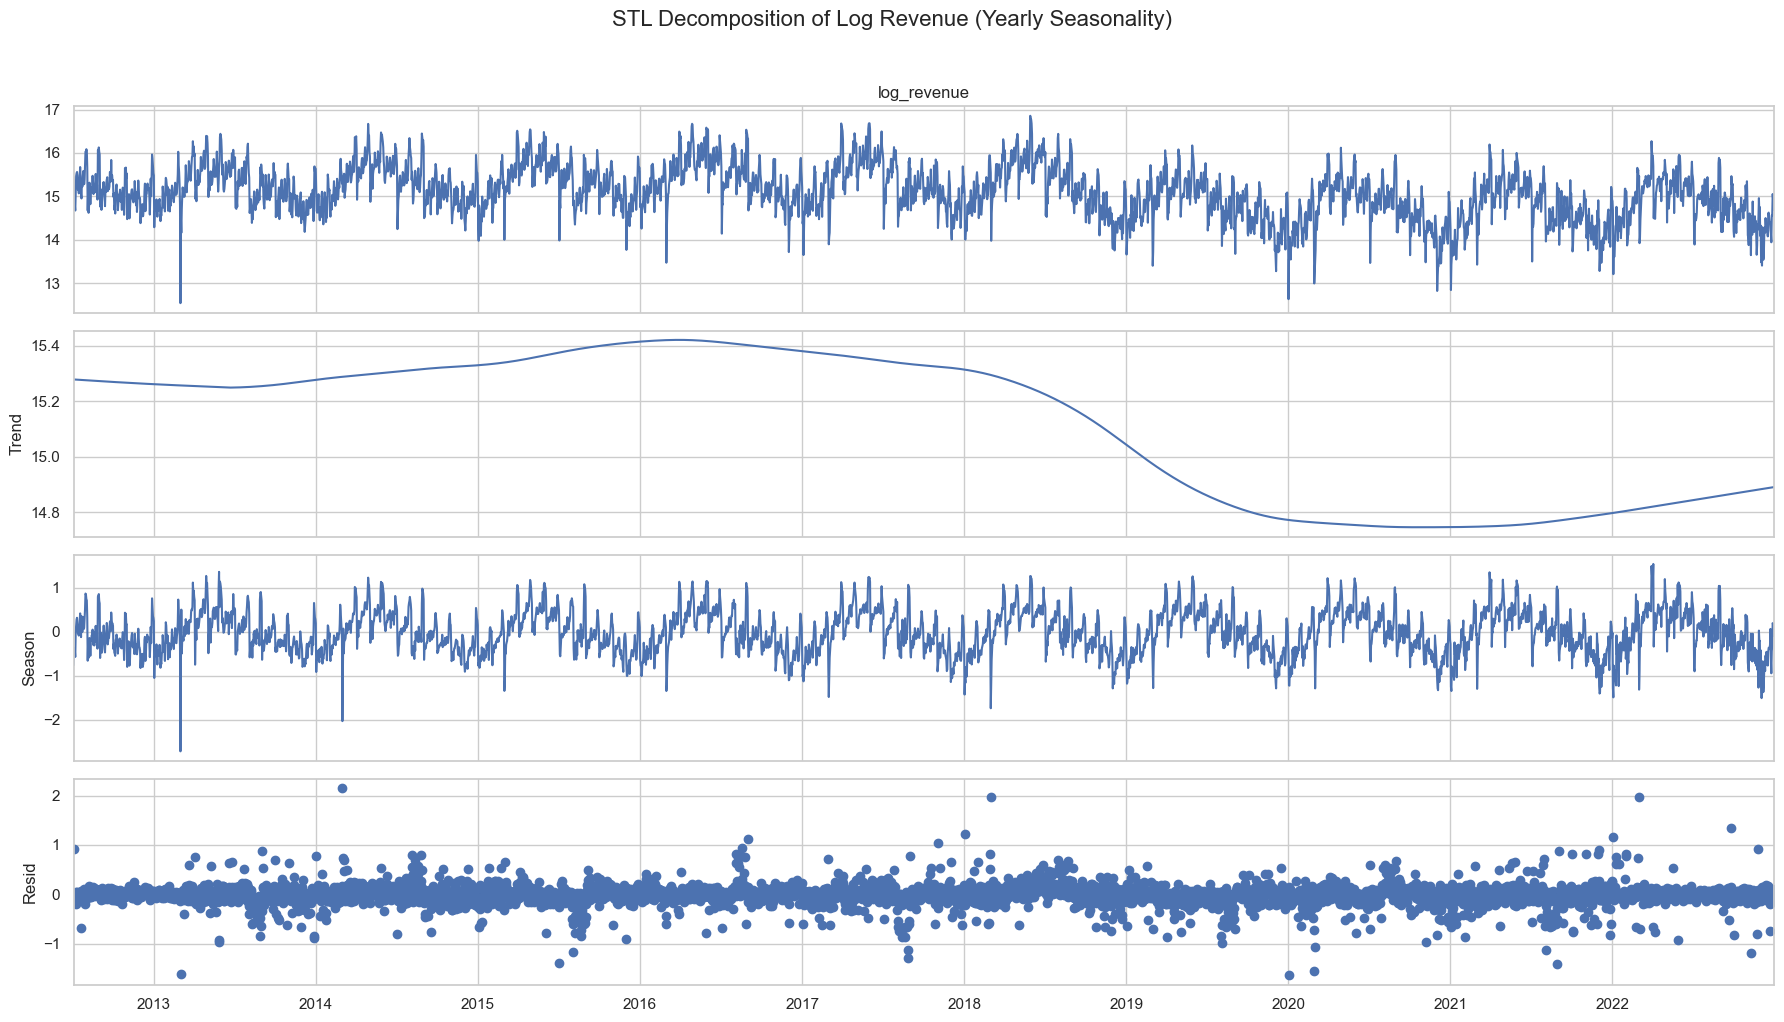

In [8]:
from statsmodels.tsa.seasonal import STL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Chuẩn bị dữ liệu
# =========================

stl_df = (
    sales[['date', 'revenue']]
    .drop_duplicates(subset='date')
    .sort_values('date')
    .copy()
)

stl_df['date'] = pd.to_datetime(stl_df['date']).dt.normalize()

stl_df = (
    stl_df
    .set_index('date')
    .asfreq('D')
)

# =========================
# Nội suy ngày bị thiếu
# =========================

missing_days = stl_df['revenue'].isna().sum()
print(f'Missing days after reindexing: {missing_days}')

if missing_days > 0:
    stl_df['revenue'] = (
        stl_df['revenue']
        .interpolate(method='time')
        .ffill()
        .bfill()
    )

# =========================
# Log transform
# =========================

stl_df['log_revenue'] = np.log1p(stl_df['revenue'])

# =========================
# STL Decomposition
# =========================

period = 365

if len(stl_df) > period * 2:

    stl = STL(
        stl_df['log_revenue'],
        period=period,
        robust=True
    )

    result = stl.fit()

    fig = result.plot()
    fig.set_size_inches(18, 10)

    fig.suptitle(
        'STL Decomposition of Log Revenue (Yearly Seasonality)',
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()
    plt.show()

else:
    print(
        f'Không đủ dữ liệu để chạy STL. '
        f'Cần > {period*2} quan sát, hiện có {len(stl_df)}.'
    )

**STL decomposition** xác nhận rằng sự suy giảm doanh thu từ năm 2019 chủ yếu xuất phát từ thành phần **trend**, thay vì các biến động ngắn hạn (*residual*) hoặc yếu tố mùa vụ (*seasonality*). Điều này cho thấy đây là một **thay đổi cấu trúc dài hạn** trong hiệu quả kinh doanh.

Kết quả cũng gợi ý rằng sự suy giảm doanh thu có thể liên quan đến việc giảm **tỷ lệ chuyển đổi (*conversion rate*)**, mặc dù lưu lượng truy cập (*traffic*) vẫn duy trì xu hướng tăng trưởng trong cùng giai đoạn.

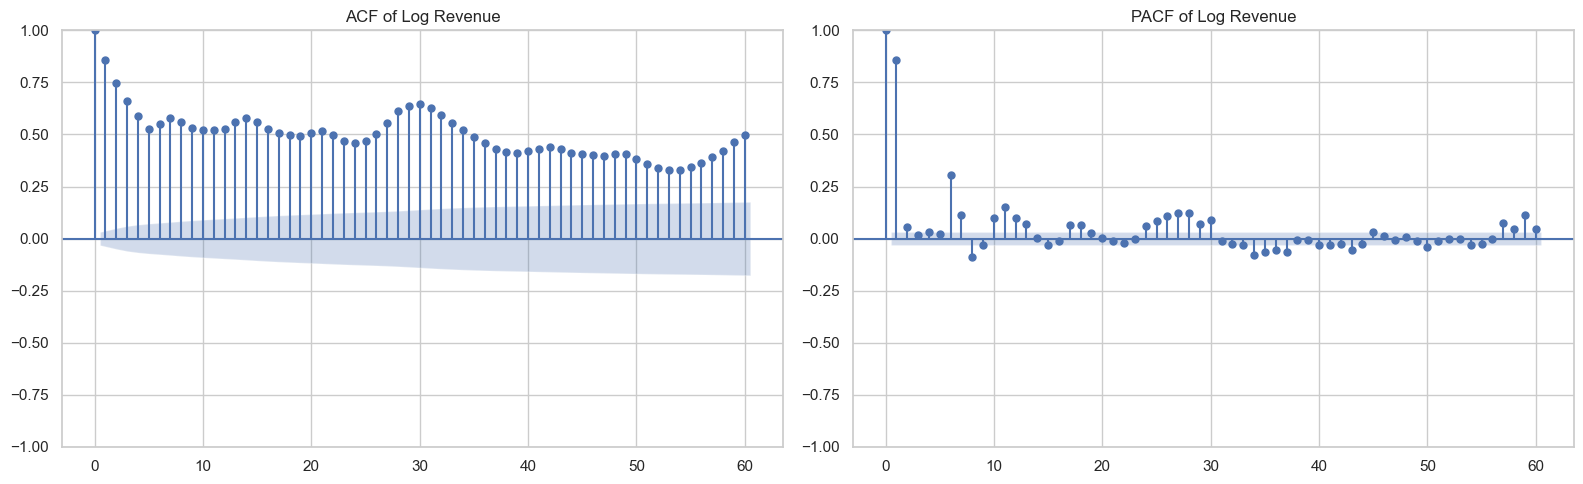

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# =========================================================
# ACF & PACF Analysis
# =========================================================

series = stl_df['log_revenue'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF
plot_acf(
    series,
    lags=60,
    ax=axes[0]
)
axes[0].set_title('ACF of Log Revenue')

# PACF
plot_pacf(
    series,
    lags=60,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title('PACF of Log Revenue')

plt.tight_layout()
plt.show()


**ACF** giảm chậm qua nhiều độ trễ và duy trì tương quan dương cao, cho thấy chuỗi doanh thu chứa **xu hướng dài hạn** và **yếu tố mùa vụ** rõ rệt. Việc ACF không nhanh chóng tiến về 0 cũng cho thấy chuỗi chưa hoàn toàn dừng.

**PACF** xuất hiện đỉnh rất mạnh tại **lag 1** rồi giảm nhanh ở các độ trễ tiếp theo, cho thấy thành phần **tự hồi quy (AR)** chủ yếu tập trung ở bậc thấp. Kết hợp với ACF, có thể thấy chuỗi doanh thu chịu ảnh hưởng đồng thời của **động lực ngắn hạn**, **xu hướng dài hạn** và **mùa vụ**.

In [11]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

# =========================================================
# STATIONARITY TEST (ADF & KPSS)
# =========================================================

stationary_series = stl_df['log_revenue'].dropna()

def run_stationarity_test(series, label):

    print("\n" + "=" * 50)
    print(label)
    print("=" * 50)

    # =====================================================
    # ADF TEST
    # =====================================================

    adf_result = adfuller(series, autolag='AIC')

    print('\n[ADF TEST]')
    print(f'ADF Statistic : {adf_result[0]:.6f}')
    print(f'p-value       : {adf_result[1]:.6f}')
    print(f'Used Lag      : {adf_result[2]}')
    print(f'Observations  : {adf_result[3]}')

    print('Critical Values:')
    for key, value in adf_result[4].items():
        print(f'  {key}: {value:.6f}')

    if adf_result[1] < 0.05:
        print('Conclusion    : Reject H0 -> chuỗi dừng')
    else:
        print('Conclusion    : Fail to Reject H0 -> chuỗi chưa dừng')

    # =====================================================
    # KPSS TEST
    # =====================================================

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        kpss_result = kpss(
            series,
            regression='c',
            nlags='auto'
        )

    print('\n[KPSS TEST]')
    print(f'KPSS Statistic: {kpss_result[0]:.6f}')
    print(f'p-value       : {kpss_result[1]:.6f}')
    print(f'Used Lags     : {kpss_result[2]}')

    print('Critical Values:')
    for key, value in kpss_result[3].items():
        print(f'  {key}: {value:.6f}')

    if kpss_result[1] < 0.05:
        print('Conclusion    : Reject H0 -> chuỗi chưa dừng')
    else:
        print('Conclusion    : Fail to Reject H0 -> chuỗi dừng')


# =========================================================
# RUN TEST
# =========================================================

run_stationarity_test(
    stationary_series,
    'STATIONARITY TEST FOR LOG REVENUE'
)


STATIONARITY TEST FOR LOG REVENUE

[ADF TEST]
ADF Statistic : -2.314354
p-value       : 0.167380
Used Lag      : 29
Observations  : 3803
Critical Values:
  1%: -3.432071
  5%: -2.862300
  10%: -2.567175
Conclusion    : Fail to Reject H0 -> chuỗi chưa dừng

[KPSS TEST]
KPSS Statistic: 2.831259
p-value       : 0.010000
Used Lags     : 36
Critical Values:
  10%: 0.347000
  5%: 0.463000
  2.5%: 0.574000
  1%: 0.739000
Conclusion    : Reject H0 -> chuỗi chưa dừng


Cả hai kiểm định **ADF** (*p-value = 0.167*) và **KPSS** (*p-value = 0.01*) đều cho thấy chuỗi `log_revenue` **chưa có tính dừng**. Điều này phản ánh sự tồn tại của xu hướng dài hạn và các thành phần phụ thuộc theo thời gian. Do đó, chuỗi cần được **sai phân bậc 1** để đạt tính dừng trước khi xây dựng mô hình dự báo.

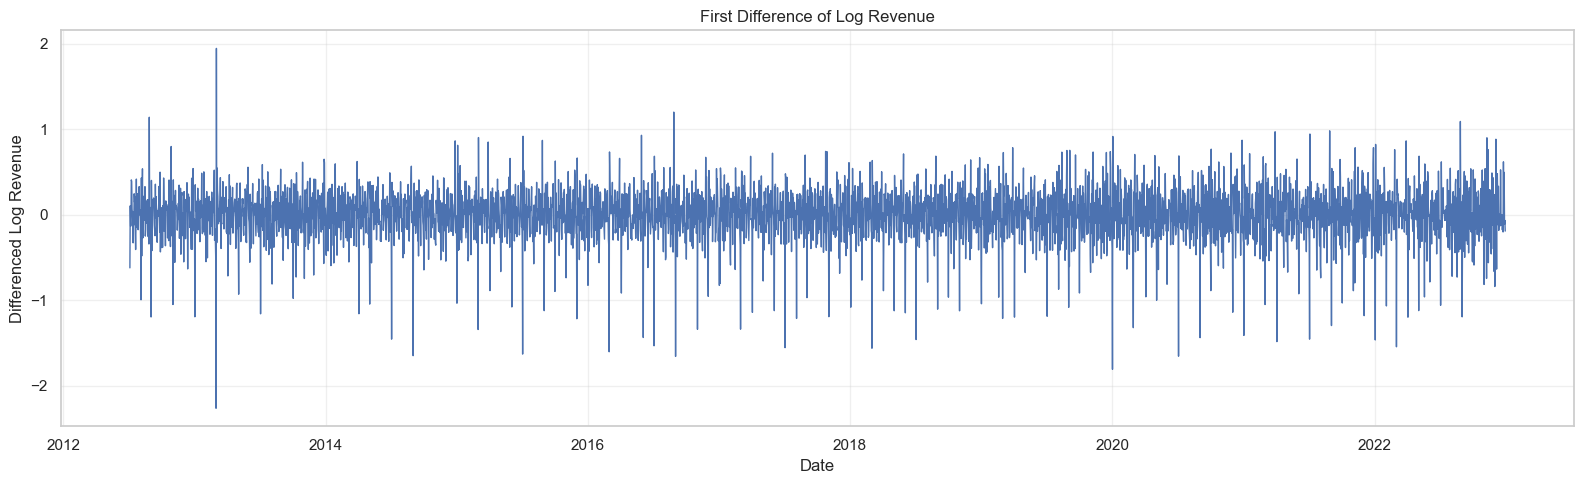

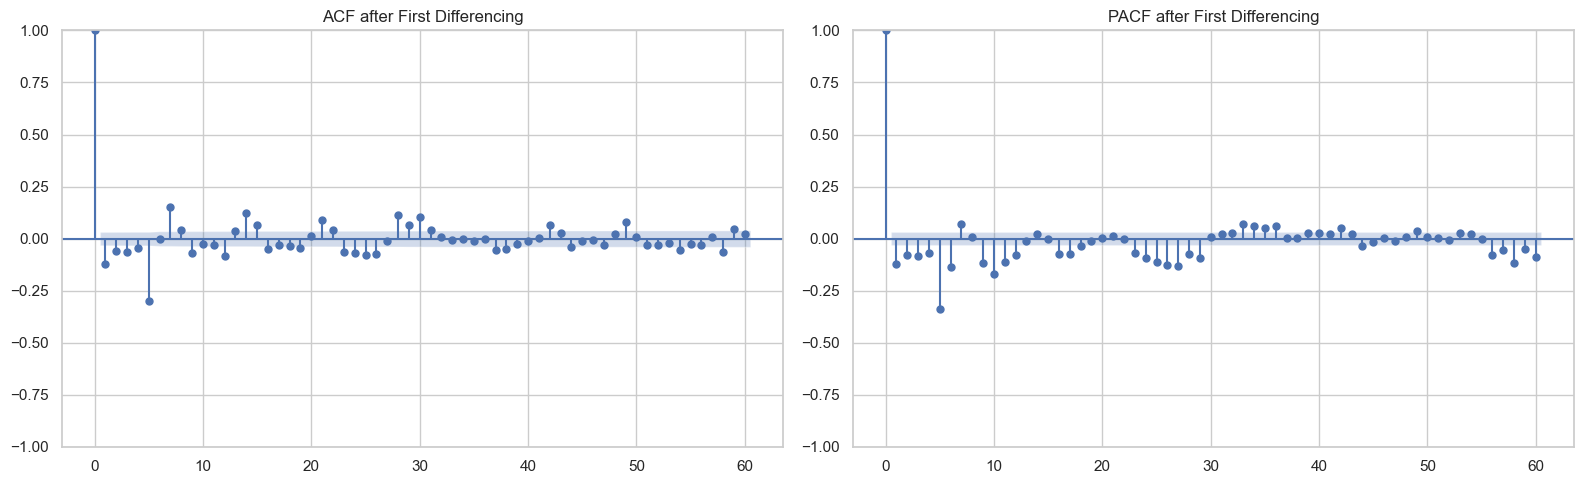

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# =========================================================
# FIRST DIFFERENCING
# =========================================================

stl_df['log_revenue_diff1'] = stl_df['log_revenue'].diff()

diff_series = stl_df['log_revenue_diff1'].dropna()

# =========================================================
# VISUALIZE FIRST DIFFERENCE SERIES
# =========================================================

plt.figure(figsize=(16, 5))

plt.plot(
    diff_series.index,
    diff_series.values,
    linewidth=1
)

plt.title('First Difference of Log Revenue')
plt.xlabel('Date')
plt.ylabel('Differenced Log Revenue')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# ACF & PACF AFTER FIRST DIFFERENCING
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF
plot_acf(
    diff_series,
    lags=60,
    ax=axes[0]
)

axes[0].set_title('ACF after First Differencing')

# PACF
plot_pacf(
    diff_series,
    lags=60,
    ax=axes[1],
    method='ywm'
)

axes[1].set_title('PACF after First Differencing')

plt.tight_layout()
plt.show()



Sau khi **sai phân bậc 1**, chuỗi `log_revenue` dao động quanh mức 0 với biên độ tương đối ổn định và không còn xu hướng dài hạn rõ rệt. Điều này cho thấy thành phần xu hướng đã được loại bỏ hiệu quả, giúp chuỗi tiến gần hơn đến **tính dừng** và phù hợp hơn cho các phân tích chuỗi thời gian.

In [14]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

# =========================================================
# STATIONARITY TEST AFTER FIRST DIFFERENCING
# =========================================================

diff_series = stl_df['log_revenue'].diff().dropna()

def run_stationarity_test(series, label):

    print("\n" + "=" * 50)
    print(label)
    print("=" * 50)

    # =====================================================
    # ADF TEST
    # =====================================================

    adf_result = adfuller(series, autolag='AIC')

    print('\n[ADF TEST]')
    print(f'ADF Statistic : {adf_result[0]:.6f}')
    print(f'p-value       : {adf_result[1]:.6f}')
    print(f'Used Lag      : {adf_result[2]}')
    print(f'Observations  : {adf_result[3]}')

    print('Critical Values:')
    for key, value in adf_result[4].items():
        print(f'  {key}: {value:.6f}')

    if adf_result[1] < 0.05:
        print('Conclusion    : Reject H0 -> chuỗi dừng')
    else:
        print('Conclusion    : Fail to Reject H0 -> chuỗi chưa dừng')

    # =====================================================
    # KPSS TEST
    # =====================================================

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        kpss_result = kpss(
            series,
            regression='c',
            nlags='auto'
        )

    print('\n[KPSS TEST]')
    print(f'KPSS Statistic: {kpss_result[0]:.6f}')
    print(f'p-value       : {kpss_result[1]:.6f}')
    print(f'Used Lags     : {kpss_result[2]}')

    print('Critical Values:')
    for key, value in kpss_result[3].items():
        print(f'  {key}: {value:.6f}')

    if kpss_result[1] < 0.05:
        print('Conclusion    : Reject H0 -> chuỗi chưa dừng')
    else:
        print('Conclusion    : Fail to Reject H0 -> chuỗi dừng')


# =========================================================
# RUN TEST
# =========================================================

run_stationarity_test(
    diff_series,
    'STATIONARITY TEST AFTER FIRST DIFFERENCING'
)


STATIONARITY TEST AFTER FIRST DIFFERENCING

[ADF TEST]
ADF Statistic : -24.800850
p-value       : 0.000000
Used Lag      : 28
Observations  : 3803
Critical Values:
  1%: -3.432071
  5%: -2.862300
  10%: -2.567175
Conclusion    : Reject H0 -> chuỗi dừng

[KPSS TEST]
KPSS Statistic: 0.015013
p-value       : 0.100000
Used Lags     : 143
Critical Values:
  10%: 0.347000
  5%: 0.463000
  2.5%: 0.574000
  1%: 0.739000
Conclusion    : Fail to Reject H0 -> chuỗi dừng



Cả hai kiểm định **ADF** và **KPSS** đều cho thấy chuỗi `log_revenue` sau **sai phân bậc 1** đã đạt **tính dừng**. ADF bác bỏ giả thuyết tồn tại nghiệm đơn vị (*p-value < 0.001*), trong khi KPSS không bác bỏ giả thuyết chuỗi dừng (*p-value = 0.10*). Kết quả này xác nhận rằng thành phần xu hướng dài hạn đã được loại bỏ hiệu quả và chuỗi trở nên ổn định hơn theo thời gian.